In [1]:
import wandb
import pandas as pd
import numpy as np
import json
import seaborn as sns

from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
api = wandb.Api()

In [3]:
runs = api.runs(path="harvardml/opt-olmo")

In [4]:
optimizers = ['sgdw', 'adamw', 'novagradw_ours', 'adafactorw', 'lionw', 'signsgd',  'sophiag',] 
display_names = ['SGD', 'Adam', 'NovoGrad', 'Adafactor', 'Lion', 'Sign SGD', 'Sophia G',]
colors = sns.color_palette('Set2', n_colors=len(optimizers))

color_map = dict(zip(optimizers, colors))
name_map = dict(zip(optimizers, display_names))

In [5]:
df = pd.DataFrame()

steps = [100, 300, 500, 900, 1700, 2900, 4900, 8500, 14600, 25000]
step = 25000
groups = ["optimizers-llama-1"]
plot_key = "learning_rate"
display_key = "Learning Rate"

for run in runs:
    if run.group in groups:
        history = run.history(samples=25000, 
                        keys=[
                            "eval/c4_val/CrossEntropyLoss", 
                            "train/CrossEntropyLoss", 
                            "optim/total_grad_norm",
                            ])
    
        run_dict = {}
        run_dict["id"] = run.id
        run_dict["group"] = run.group
        run_dict["optimizer"] = run.config["optimizer"]["name"]
        run_dict[plot_key] = run.config["optimizer"][plot_key]

        if run.group == "optimizers-1" and run_dict["optimizer"] == "sgdw":
            continue
        
        if "eval/c4_val/CrossEntropyLoss" in history:
            if step not in list(history["_step"]):
                run_dict["val_loss"] = 10.0
            else:
                run_dict["val_loss"] = list(history[history["_step"] == step]["eval/c4_val/CrossEntropyLoss"])[0]
                run_dict["step"] = step
        else:
            run_dict["val_loss"] = np.nan
            run_dict["step"] = np.nan
        if run_dict["optimizer"] == "novagradw" and run.config["optimizer"]["att_correction"]:
            run_dict["optimizer"] = "novagradw_ours"
        if (run_dict["optimizer"] == "adafactorw" and 
            "neuron_only" in run.config["optimizer"] and
            run.config["optimizer"]["neuron_only"]
        ):
            run_dict["optimizer"] = "adafactorw_oneside"
        run_df = pd.DataFrame(run_dict, index=[0])
        df = pd.concat([df, run_df])

In [6]:
df

,id,group,optimizer,learning_rate,val_loss,step
0,vw4ypa7g,optimizers-llama-1,lionw,0.100000,10.000000,NaN
0,bzo7jvoc,optimizers-llama-1,lionw,0.003160,7.157638,25000.0
0,p1bz8n82,optimizers-llama-1,adafactorw,0.010000,3.285920,25000.0
0,omdiu9ro,optimizers-llama-1,adafactorw,0.000316,3.149381,25000.0
0,ls84uda3,optimizers-llama-1,lionw,0.000100,3.124239,25000.0
0,jcsd7h3q,optimizers-llama-1,lionw,0.031600,10.000000,NaN
0,vu2s54vo,optimizers-llama-1,lionw,0.001000,3.080427,25000.0
0,feuomuor,optimizers-llama-1,lionw,0.010000,10.000000,NaN
0,8hofmqbk,optimizers-llama-1,adafactorw,0.000100,3.359242,25000.0
0,af8a02ln,optimizers-llama-1,novagradw_ours,1.000000,NaN,NaN


In [7]:
len(df)

45

In [8]:
df["optimizer"].unique()

array(['lionw', 'adafactorw', 'novagradw_ours', 'sgdw', 'adamw'],
      dtype=object)

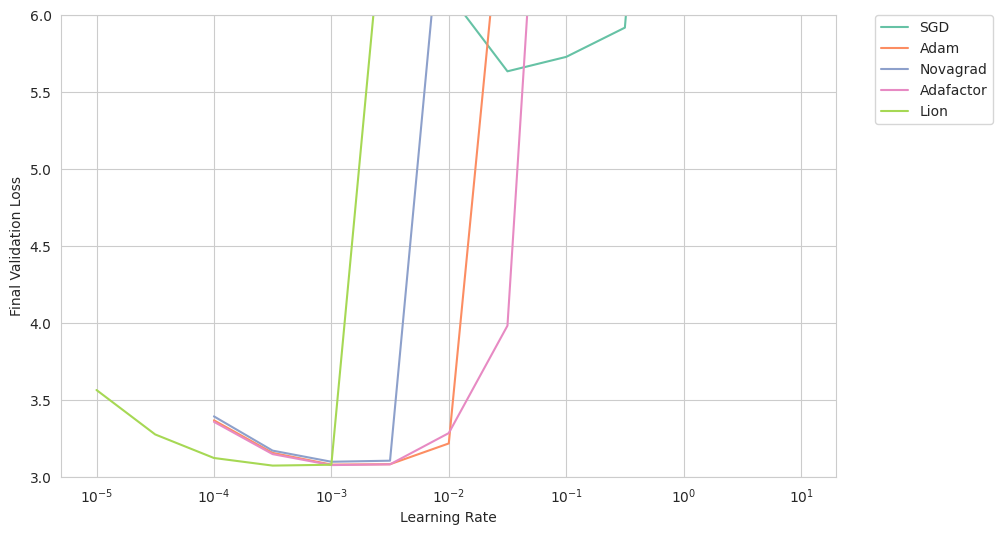

In [9]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))  # Larger figure size


best_lrs = {}
for optimizer in optimizers:
    if optimizer in df["optimizer"].unique():
        optimizer_df = df[df["optimizer"] == optimizer]
        optimizer_df = optimizer_df.sort_values(by=plot_key)
        optimizer_df = optimizer_df.groupby(plot_key).min().reset_index()
        plt.plot(optimizer_df[plot_key], optimizer_df["val_loss"], label=name_map[optimizer], color=color_map[optimizer])
        
        best_lr = optimizer_df[plot_key][optimizer_df["val_loss"].idxmin()]
        best_lrs[optimizer] = best_lr

plt.xscale("log")
#plt.yscale("log")
plt.ylim(3, 6)
plt.legend()
plt.xlabel(display_key)
plt.ylabel("Final Validation Loss")
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
plt.show()

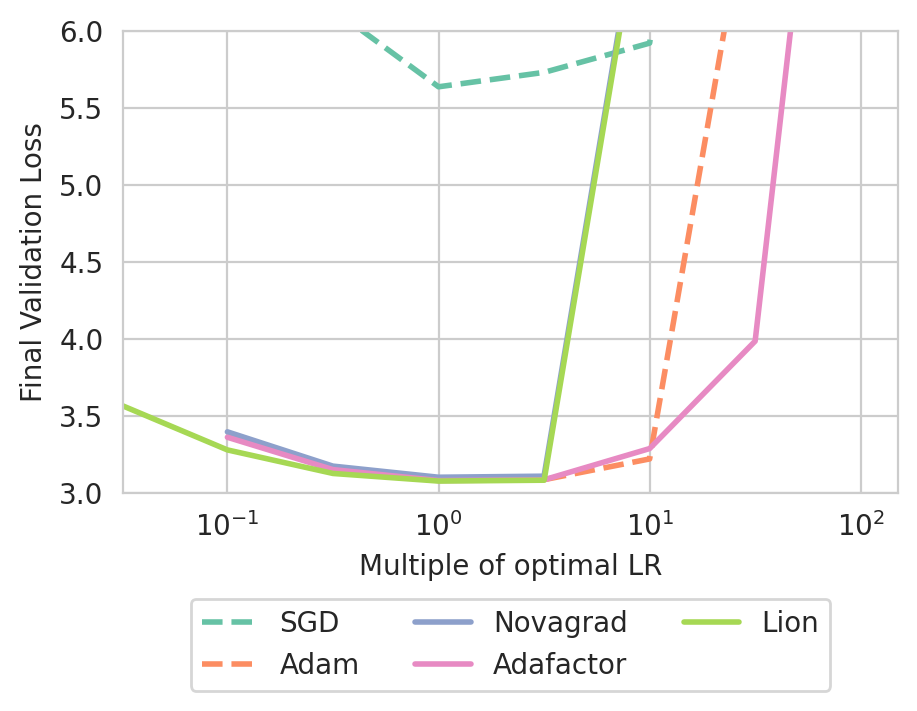

In [10]:
sns.set_style("whitegrid")
plt.figure(figsize=(5, 3), dpi=200)  # Larger figure size

df_div = df.copy()

adam_lr = best_lrs["adamw"]
multipliers = {k: adam_lr / v for k,v in best_lrs.items()}

for optimizer in optimizers:
    if optimizer in df["optimizer"].unique():
        optimizer_df = df[df["optimizer"] == optimizer]
        optimizer_df = optimizer_df.sort_values(by="learning_rate")
        # take minimal value for each learning rate
        optimizer_df = optimizer_df.groupby("learning_rate").min().reset_index()
        plt.plot(
            multipliers[optimizer] * optimizer_df["learning_rate"] / adam_lr, 
            optimizer_df["val_loss"], 
            label=name_map[optimizer],
            linewidth=2,
            color=color_map[optimizer],
            linestyle='--' if optimizer in ['adamw', 'sgdw'] else '-'
        )

plt.xscale("log")
plt.xlim(3.2e-2, 1.5e2)
plt.ylim(3.0, 6) #3.4)
plt.xlabel("Multiple of optimal LR")
plt.ylabel("Final Validation Loss")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), fancybox=True, shadow=False, ncol=len(optimizers) /2)
plt.show()

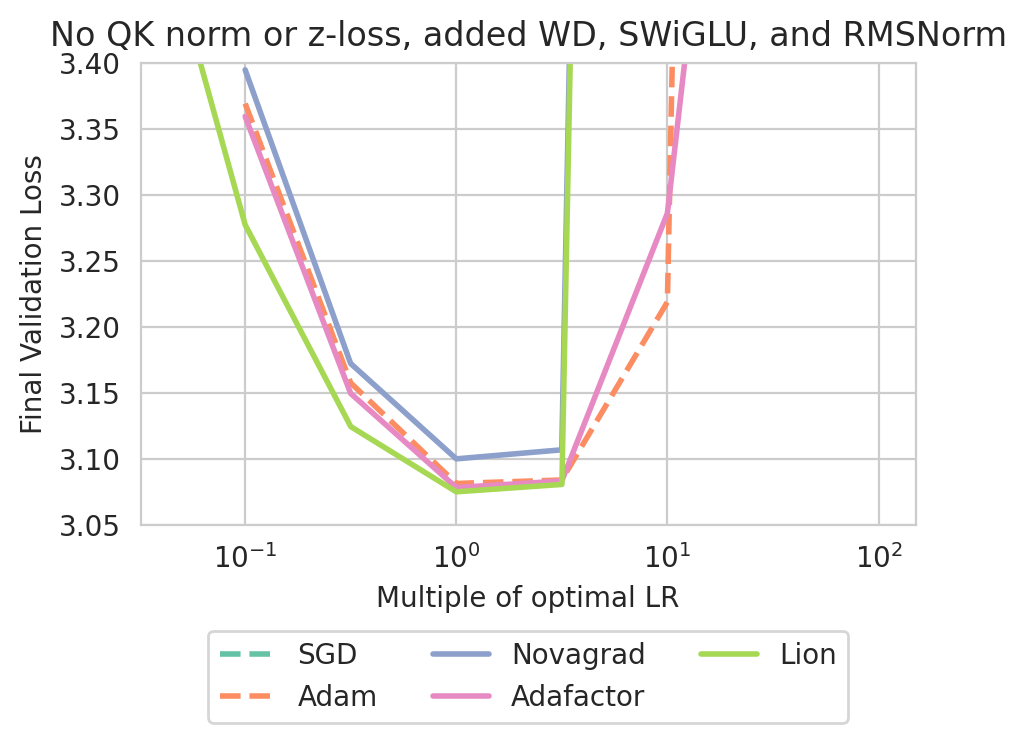

In [11]:
sns.set_style("whitegrid")
plt.figure(figsize=(5, 3), dpi=200)  # Larger figure size

df_div = df.copy()

adam_lr = best_lrs["adamw"]
multipliers = {k: adam_lr / v for k,v in best_lrs.items()}

for optimizer in optimizers:
    if optimizer in df["optimizer"].unique():
        optimizer_df = df[df["optimizer"] == optimizer]
        optimizer_df = optimizer_df.sort_values(by="learning_rate")
        # take minimal value for each learning rate
        optimizer_df = optimizer_df.groupby("learning_rate").min().reset_index()
        plt.plot(
            multipliers[optimizer] * optimizer_df["learning_rate"] / adam_lr, 
            optimizer_df["val_loss"], 
            label=name_map[optimizer],
            linewidth=2,
            color=color_map[optimizer],
            linestyle='--' if optimizer in ['adamw', 'sgdw'] else '-'
        )

plt.xscale("log")
plt.xlim(3.2e-2, 1.5e2)
plt.ylim(3.05, 3.4)
plt.xlabel("Multiple of optimal LR")
plt.ylabel("Final Validation Loss")
plt.title("No QK norm or z-loss, added WD, SWiGLU, and RMSNorm")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), fancybox=True, shadow=False, ncol=len(optimizers) /2)
plt.show()